In [1]:
import os
import gc
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATConv, GlobalAttention
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

/opt/conda/envs/rapids-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define the functional map

In [2]:
FUNCTIONAL_MAP = {
    'TSS200': 0, 'TSS1500': 1, '1stExon': 2, 
    "5'UTR": 3, 'Body': 4, "3'UTR": 5, 'Other': 6
}

## Build the Chromosome topologies

In [3]:
def build_chromosome_topologies(manifest_df, common_probes, max_linear_dist_bp=1000):
    manifest = manifest_df[manifest_df['IlmnID'].isin(common_probes)].copy()
    manifest['CHR'] = manifest['CHR'].astype(str).str.replace('chr', '')
    manifest = manifest[manifest['CHR'].isin([str(i) for i in range(1, 23)])]
    manifest['MAPINFO'] = manifest['MAPINFO'].astype(int)
    
    chr_topologies = {}
    
    for c in range(1, 23):
        chr_str = str(c)
        sub = manifest[manifest['CHR'] == chr_str].sort_values(by='MAPINFO').reset_index(drop=True)
        probe_list = sub['IlmnID'].tolist()
        probe_to_idx = {p: i for i, p in enumerate(probe_list)}
        positions = sub['MAPINFO'].values
        n_nodes = len(probe_list)
        
        # A. Encode primary functional annotation
        func_labels = np.full(n_nodes, FUNCTIONAL_MAP['Other'], dtype=np.int64)
        for idx, row in sub.iterrows():
            grps = str(row.get('UCSC_RefGene_Group', '')).split(';')
            if grps and grps[0] in FUNCTIONAL_MAP:
                func_labels[idx] = FUNCTIONAL_MAP[grps[0]]
                
        # B. EXPLICIT SELF LOOPS (Fixes Empty Edge Crash & Mathematically sound for GAT)
        edges = [[i, i] for i in range(n_nodes)]
        
        # C. 1D Linear Adjacency Edges
        for i in range(n_nodes - 1):
            if 0 < (positions[i+1] - positions[i]) <= max_linear_dist_bp:
                edges.append([i, i + 1])
                edges.append([i + 1, i])
                
        # D. Shared Genic Annotation Edges
        gene_groups = {}
        for idx, row in sub.iterrows():
            genes = str(row.get('UCSC_RefGene_Name', '')).split(';')
            if genes and genes[0] not in ('', 'nan'):
                gene = genes[0]
                gene_groups.setdefault(gene, []).append(idx)
                
        for members in gene_groups.values():
            if 1 < len(members) <= 50:
                for i in range(len(members)):
                    for j in range(i + 1, len(members)):
                        edges.append([members[i], members[j]])
                        edges.append([members[j], members[i]])
                        
        # Because we initialized with self-loops, 'edges' is guaranteed non-empty
        edge_arr = np.unique(np.array(edges), axis=0).T
        edge_index = torch.tensor(edge_arr, dtype=torch.long)
            
        chr_topologies[c] = {
            'probes': probe_list,
            'edge_index': edge_index,
            'func_type': torch.tensor(func_labels, dtype=torch.long),
            'n_nodes': n_nodes
        }
        
    return chr_topologies

## PyTorch dataset and Trasposed Collator

In [4]:
LABEL_MAP = {'Control': 0.0, 'PD': 1.0}

class WholeBloodMethylationDataset(Dataset):
    def __init__(self, m_matrix_df, pheno_df, cell_cols, chr_topologies):
        self.sample_ids = pheno_df.index.tolist()
        
        # Explicit label encoding for BCEWithLogitsLoss
        labels = pheno_df['Sample_Group'].map(LABEL_MAP)
        if labels.isna().any():
            unknown_labels = sorted(pheno_df.loc[labels.isna(), 'Sample_Group'].astype(str).unique().tolist())
            raise ValueError(f"Unexpected Sample_Group values: {unknown_labels}")
        self.labels = labels.to_numpy(dtype=np.float32)
        
        self.cell_props = pheno_df[cell_cols].values.astype(np.float32)
        self.chr_topologies = chr_topologies
        
        self.chr_m_values = {}
        for c in range(1, 23):
            probes = chr_topologies[c]['probes']
            # Safe slice: guarantees no missing probes because df was pre-subsetted
            self.chr_m_values[c] = m_matrix_df.loc[self.sample_ids, probes].values.astype(np.float32)
            
    def __len__(self):
        return len(self.sample_ids)
        
    def __getitem__(self, idx):
        chr_graphs = []
        for c in range(1, 23):
            raw_x = torch.from_numpy(self.chr_m_values[c][idx]).unsqueeze(1)
            topo = self.chr_topologies[c]
            
            data = Data(
                x=raw_x,
                edge_index=topo['edge_index'],
                func_type=topo['func_type']
            )
            chr_graphs.append(data)
            
        u = torch.from_numpy(self.cell_props[idx])
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return chr_graphs, u, y


def chromosome_collate_fn(batch):
    batched_chromosomes = []
    graphs_per_sample = [item[0] for item in batch]
    u_tensor = torch.stack([item[1] for item in batch])
    y_tensor = torch.stack([item[2] for item in batch])
    
    for chr_idx in range(22):
        chr_list = [graphs[chr_idx] for graphs in graphs_per_sample]
        batched_chromosomes.append(Batch.from_data_list(chr_list))
        
    return batched_chromosomes, u_tensor, y_tensor

## Chromosome-Parallel GAT Architecture

In [5]:
class ChromosomeParallelGAT(nn.Module):
    def __init__(self, num_node_classes=7, chr_embed_dim=16, cell_prop_dim=6):
        super(ChromosomeParallelGAT, self).__init__()
        
        self.func_embedding = nn.Embedding(num_embeddings=num_node_classes, embedding_dim=8)
        
        # add_self_loops=False because we explicitly defined them in the topology builder
        self.gat1 = GATConv(in_channels=9, out_channels=8, heads=2, concat=True, add_self_loops=False)
        self.gat2 = GATConv(in_channels=16, out_channels=chr_embed_dim, heads=1, concat=True, add_self_loops=False)
        
        self.gate_nn = nn.Sequential(
            nn.Linear(chr_embed_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        self.pool = GlobalAttention(gate_nn=self.gate_nn)
        
        fused_dim = (22 * chr_embed_dim) + cell_prop_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
        
    def forward(self, batched_chrs, u_cells):
        chr_embeddings = []
        for c_idx in range(22):
            batch = batched_chrs[c_idx]
            
            emb_func = self.func_embedding(batch.func_type)
            node_feat = torch.cat([batch.x, emb_func], dim=1)
            
            h = torch.relu(self.gat1(node_feat, batch.edge_index))
            h = torch.relu(self.gat2(h, batch.edge_index))
            
            chr_emb = self.pool(h, batch.batch)
            chr_embeddings.append(chr_emb)
            
        genome_vector = torch.cat(chr_embeddings, dim=1)
        fused = torch.cat([genome_vector, u_cells], dim=1)
        return self.classifier(fused)

## 5-Fold CV

In [20]:
m_matrix_full = pd.read_feather("/workspace/data/GSE111629_data_test.feather")

This here fixes the m_matrix since the current parquet representation lacks all metadata/pheno columns including Sample_Name which causes failures further below...

In [ ]:
m_matrix_with_id = (
    m_matrix_full.copy()
    if 'Sample_Name' in m_matrix_full.columns
    else m_matrix_full.reset_index().rename(columns={m_matrix_full.index.name or 'index': 'Sample_Name'})
)

cols_to_keep = ['Sample_Name'] + [
    c for c in m_matrix_with_id.columns
    if c != 'Sample_Name' and c not in pheno_df.columns
]

m_matrix_full_reduced = m_matrix_with_id[cols_to_keep]
output_path = os.path.join("/workspace/data", "GSE111629_m_matrix_full_reduced.parquet")
m_matrix_full_reduced.to_parquet(output_path, index=False)
print(f"Saved to: {output_path}")

Saved to: /workspace/data/m_matrix_full_reduced.parquet


In [ ]:
m_matrix_full_reduced

In [33]:
m_matrix_full_reduced.head()

,cg16619049,cg23100540,cg18147296,cg13938959,cg12445832,cg23999112,cg11527153,cg27573606,cg04195702,cg08128007,...,cg19324023,cg09635994,cg19004771,cg20569369,cg26034629,cg25232725,cg05615487,cg22122449,cg08423507,cg19565306
Sample_Name,,,,,,,,,,,,,,,,,,,,,
GSM3035401,-0.391231,-1.572003,4.406984,0.778984,-0.906040,0.875549,4.271860,5.154080,3.761474,2.946690,...,3.354123,2.004086,1.929260,2.892161,4.913450,2.807751,4.782970,4.457486,5.246001,-6.148653
GSM3035402,-0.294673,-1.753355,3.439536,1.494787,-0.710042,0.808505,3.376785,5.194660,3.859485,3.366361,...,4.178481,1.938704,2.545114,2.160673,4.978455,2.912098,4.853534,4.736333,5.141731,-6.166355
GSM3035403,-1.009068,-1.895521,4.048525,0.860604,-0.790885,0.388188,4.297615,5.249513,3.691613,2.774799,...,3.367879,1.731055,1.931527,2.390308,5.219790,2.573055,4.933959,5.374524,5.142147,-6.167470
GSM3035404,-0.718404,-1.937458,3.281372,1.547149,-0.438353,1.122274,2.447532,5.334864,3.865556,4.230160,...,2.990683,2.210517,1.962918,2.375698,4.828473,3.111890,4.963863,3.586690,5.095090,-6.178808
GSM3035405,-0.817407,-1.902594,3.006591,1.674067,-0.705906,1.484803,3.157014,4.982922,4.555103,2.642256,...,3.262536,1.902270,1.696990,2.303311,5.145214,2.800162,4.069010,4.884013,5.142816,-6.166770


In [7]:

pheno_path = "/workspace/data/GSE111629_pheno_data.parquet"
m_matrix_path = "/workspace/data/GSE111629_m_matrix_full_reduced.parquet"
manifest_path = "/workspace/data/infinium450k_manifest.parquet"

LABEL_MAP = {'Control': 0, 'PD': 1}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing GAT Pipeline on: {device}")

pheno_df = pd.read_parquet(pheno_path)
if pheno_df.index.name != "Sample_Name":
    pheno_df = pheno_df.set_index("Sample_Name")
    
cell_cols = ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']
m_matrix_df = pd.read_parquet(m_matrix_path)
manifest_df = pd.read_parquet(manifest_path) 

m_matrix_df.set_index("Sample_Name", inplace=True)

# Strict validation to prevent index mismatch
common_probes = list(set(m_matrix_df.columns).intersection(set(manifest_df['IlmnID'])))
m_matrix_df = m_matrix_df[common_probes] # Discard unused columns to save RAM early
print(f"Total overlapping autosome probes: {len(common_probes):,}")

print("Building chromosome 1D adjacency and genic graphs...")
chr_topologies = build_chromosome_topologies(manifest_df, common_probes)

y = pheno_df['Sample_Group'].map(LABEL_MAP)
if y.isna().any():
    unknown_labels = sorted(pheno_df.loc[y.isna(), 'Sample_Group'].astype(str).unique().tolist())
    raise ValueError(f"Unexpected Sample_Group values: {unknown_labels}")
y = y.to_numpy(dtype=np.int64)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_aucs, pr_aucs = [], []
batch_size = 16  
epochs = 40
lr = 2e-4

for fold, (train_idx, test_idx) in enumerate(skf.split(pheno_df, y)):
    print(f"\n--- Fold {fold + 1} ---")
    train_pheno = pheno_df.iloc[train_idx]
    test_pheno = pheno_df.iloc[test_idx]
    
    train_ds = WholeBloodMethylationDataset(m_matrix_df, train_pheno, cell_cols, chr_topologies)
    test_ds = WholeBloodMethylationDataset(m_matrix_df, test_pheno, cell_cols, chr_topologies)
    
    train_loader = DataLoader(train_ds, 
                              batch_size=batch_size, 
                              shuffle=True, 
                              collate_fn=chromosome_collate_fn,
                              num_workers=4,
                              pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=chromosome_collate_fn)
    
    model = ChromosomeParallelGAT().to(device)
    
    # Explicit dtype declaration for pos_weight
    train_labels = train_pheno['Sample_Group'].map(LABEL_MAP)
    if train_labels.isna().any():
        unknown_labels = sorted(train_pheno.loc[train_labels.isna(), 'Sample_Group'].astype(str).unique().tolist())
        raise ValueError(f"Unexpected Sample_Group values in training fold: {unknown_labels}")
    train_labels = train_labels.to_numpy(dtype=np.float32)
    positives = float((train_labels == 1.0).sum())
    negatives = float((train_labels == 0.0).sum())
    if positives == 0:
        raise ValueError("Training fold has no positive samples, cannot compute pos_weight")
    pos_weight = torch.tensor([negatives / positives], device=device, dtype=torch.float32)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    
    # Training
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for batched_chrs, u_cells, batch_y in train_loader:
            
            # Asynchronous memory transfer
            batched_chrs = [c.to(device, non_blocking=True) for c in batched_chrs]
            u_cells = u_cells.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            logits = model(batched_chrs, u_cells).squeeze(1)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            # VRAM Fragmentation Protection
            del batched_chrs, u_cells, batch_y, logits, loss
            
    # Evaluation
    model.eval()
    preds, truths = [], []
    with torch.no_grad():
        for batched_chrs, u_cells, batch_y in test_loader:
            batched_chrs = [c.to(device, non_blocking=True) for c in batched_chrs]
            u_cells = u_cells.to(device, non_blocking=True)
            
            logits = model(batched_chrs, u_cells).squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()
            
            preds.extend(probs)
            truths.extend(batch_y.numpy())
            
            del batched_chrs, u_cells, logits
            
    fold_roc = roc_auc_score(truths, preds)
    fold_pr = average_precision_score(truths, preds)
    roc_aucs.append(fold_roc)
    pr_aucs.append(fold_pr)
    print(f"Fold {fold + 1} | ROC AUC: {fold_roc:.4f} | PR AUC: {fold_pr:.4f}")

    # Save the model weights for downstream biological extraction
    torch.save(model.state_dict(), f"/workspace/results/gat_fold_{fold + 1}.pt")

    del model, optimizer, train_ds, test_ds
    torch.cuda.empty_cache()
    gc.collect()
    
print("\n" + "=" * 40)
print(f"Mean GAT ROC AUC: {np.mean(roc_aucs):.4f} ± {np.std(roc_aucs):.4f}")
print(f"Mean GAT PR AUC:  {np.mean(pr_aucs):.4f} ± {np.std(pr_aucs):.4f}")

Executing GAT Pipeline on: cuda
Total overlapping autosome probes: 421,114
Building chromosome 1D adjacency and genic graphs...

--- Fold 1 ---


/tmp/ipykernel_18700/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Fold 1 | ROC AUC: 0.6883 | PR AUC: 0.7273

--- Fold 2 ---


/tmp/ipykernel_18700/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Fold 2 | ROC AUC: 0.6839 | PR AUC: 0.7422

--- Fold 3 ---


...

Fold 3 | ROC AUC: 0.6846 | PR AUC: 0.7190

--- Fold 4 ---


/tmp/ipykernel_18700/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Fold 4 | ROC AUC: 0.6646 | PR AUC: 0.6952

--- Fold 5 ---


/tmp/ipykernel_18700/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Fold 5 | ROC AUC: 0.7167 | PR AUC: 0.7542

Mean GAT ROC AUC: 0.6876 ± 0.0167
Mean GAT PR AUC:  0.7276 ± 0.0202


In [12]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch_geometric.nn import GATConv, GlobalAttention
from torch_geometric.utils import softmax
from torch_geometric.data import Batch, Data

# =====================================================================
# 1. THE EXPLAINER ARCHITECTURE
# =====================================================================
# This is identical to your training architecture, but the forward pass 
# is modified to explicitly return the biological attention weights.
class GATExplainer(nn.Module):
    def __init__(self, num_node_classes=7, chr_embed_dim=16, cell_prop_dim=6):
        super(GATExplainer, self).__init__()
        self.func_embedding = nn.Embedding(num_embeddings=num_node_classes, embedding_dim=8)
        self.gat1 = GATConv(in_channels=9, out_channels=8, heads=2, concat=True, add_self_loops=False)
        self.gat2 = GATConv(in_channels=16, out_channels=chr_embed_dim, heads=1, concat=True, add_self_loops=False)
        
        self.gate_nn = nn.Sequential(
            nn.Linear(chr_embed_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
        self.pool = GlobalAttention(gate_nn=self.gate_nn)
        
        fused_dim = (22 * chr_embed_dim) + cell_prop_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, batched_chrs, u_cells):
        genome_attention = {}
        
        for c_idx in range(22):
            batch = batched_chrs[c_idx]
            
            # Forward pass through GAT layers
            emb_func = self.func_embedding(batch.func_type)
            node_feat = torch.cat([batch.x, emb_func], dim=1)
            h = torch.relu(self.gat1(node_feat, batch.edge_index))
            h = torch.relu(self.gat2(h, batch.edge_index))
            
            # --- EXTRACT BIOLOGICAL IMPORTANCE ---
            # Calculate the raw importance score for every single CpG site
            raw_gate_scores = self.gate_nn(h).view(-1)
            # Normalize scores so they sum to 1.0 across the chromosome
            cpg_attention = softmax(raw_gate_scores, batch.batch)
            
            # Store the attention weights for this chromosome
            # Shape: [num_nodes_in_batch]
            genome_attention[c_idx + 1] = cpg_attention.detach().cpu().numpy()
            
        return genome_attention

# =====================================================================
# 2. EXTRACTION LOGIC
# =====================================================================
def extract_biological_drivers(model_path, m_matrix_df, pheno_df, chr_topologies, cell_cols):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Extracting on: {device}")
    
    # 1. Initialize and Load Weights
    model = GATExplainer().to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # 2. Isolate Parkinson's Patients (We want to see what drives the PD signature)
    pd_samples = pheno_df[pheno_df['Sample_Group'] == 'PD'].index.tolist()
    print(f"Extracting drivers across {len(pd_samples)} PD patients...")
    
    # 3. Process Patients (Batch size 1 for clean extraction)
    # We will accumulate the attention weights to find the consensus drivers
    consensus_attention = {c: np.zeros(chr_topologies[c]['n_nodes']) for c in range(1, 23)}
    
    for sample in pd_samples:
        chr_graphs = []
        for c in range(1, 23):
            probes = chr_topologies[c]['probes']
            raw_x = torch.from_numpy(m_matrix_df.loc[sample, probes].values.astype(np.float32)).unsqueeze(1)
            data = Data(x=raw_x, edge_index=chr_topologies[c]['edge_index'], func_type=chr_topologies[c]['func_type'])
            chr_graphs.append(data)
            
        # Convert to PyG Batch format (batch size 1)
        batched_chrs = [Batch.from_data_list([g]).to(device) for g in chr_graphs]
        u = torch.tensor(pheno_df.loc[sample, cell_cols].values.astype(np.float32)).unsqueeze(0).to(device)
        
        # 4. Extract Attention
        with torch.no_grad():
            attention_dict = model(batched_chrs, u)
            
        for c in range(1, 23):
            consensus_attention[c] += attention_dict[c]

    # 5. Average the attention across all PD patients
    for c in range(1, 23):
        consensus_attention[c] /= len(pd_samples)
        
    return consensus_attention

# =====================================================================
# 3. MAP TO BIOLOGY & EXPORT
# =====================================================================
def map_and_export_drivers(consensus_attention, chr_topologies, manifest_df, export_path="pd_epigenetic_drivers.csv"):
    records = []
    
    for c in range(1, 23):
        probes = chr_topologies[c]['probes']
        weights = consensus_attention[c]
        
        for idx, probe in enumerate(probes):
            records.append({
                'IlmnID': probe,
                'Chromosome': c,
                'Attention_Score': weights[idx]
            })
            
    df_weights = pd.DataFrame(records)
    
    # Merge with Manifest to get Genes and Regions
    final_df = df_weights.merge(
        manifest_df[['IlmnID', 'UCSC_RefGene_Name', 'UCSC_RefGene_Group']], 
        on='IlmnID', 
        how='left'
    )
    
    # Sort by highest attention score
    final_df = final_df.sort_values(by='Attention_Score', ascending=False).reset_index(drop=True)
    final_df.to_csv(export_path, index=False)
    print(f"Top drivers exported to {export_path}")
    
    return final_df



In [9]:
# 1. Define the paths to your 5 saved models
fold_paths = [f"/workspace/results/gat_fold_{i}.pt" for i in range(1, 6)]

# 2. Initialize a master dictionary to hold the ensemble weights
master_consensus = {c: np.zeros(chr_topologies[c]['n_nodes']) for c in range(1, 23)}

print("Starting Ensemble Extraction across 5 folds...")

# 3. Loop through each fold, extract weights, and add to the master dictionary
for fold_idx, model_path in enumerate(fold_paths):
    print(f"\n--- Processing {model_path} ---")
    
    # Run the extraction function we defined earlier
    fold_consensus = extract_biological_drivers(
        model_path, 
        m_matrix_df, 
        pheno_df, 
        chr_topologies, 
        cell_cols
    )
    
    # Add this fold's weights to the master tracker
    for c in range(1, 23):
        master_consensus[c] += fold_consensus[c]

# 4. Average the weights across the 5 folds
for c in range(1, 23):
    master_consensus[c] /= 5.0

print("\nEnsemble extraction complete! Mapping to Illumina Manifest...")

# 5. Map the ensemble weights to genes and export
ensemble_drivers_df = map_and_export_drivers(
    master_consensus, 
    chr_topologies, 
    manifest_df, 
    export_path="/workspace/results/pd_ensemble_epigenetic_drivers.csv"
)

# Display the top 20 most critical biological drivers
print("\nTop 20 Consistently Weighted CpG Sites:")
print(ensemble_drivers_df.head(20))

Starting Ensemble Extraction across 5 folds...

--- Processing /workspace/results/gat_fold_1.pt ---
Extracting on: cuda
Extracting drivers across 306 PD patients...


/tmp/ipykernel_18700/3677629239.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)



--- Processing /workspace/results/gat_fold_2.pt ---
Extracting on: cuda
Extracting drivers across 306 PD patients...


/tmp/ipykernel_18700/3677629239.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)



--- Processing /workspace/results/gat_fold_3.pt ---
Extracting on: cuda
Extracting drivers across 306 PD patients...


...


--- Processing /workspace/results/gat_fold_4.pt ---
Extracting on: cuda
Extracting drivers across 306 PD patients...


/tmp/ipykernel_18700/3677629239.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)



--- Processing /workspace/results/gat_fold_5.pt ---
Extracting on: cuda
Extracting drivers across 306 PD patients...


/tmp/ipykernel_18700/3677629239.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)



Ensemble extraction complete! Mapping to Illumina Manifest...
Top drivers exported to /workspace/results/pd_ensemble_epigenetic_drivers.csv

Top 20 Consistently Weighted CpG Sites:
        IlmnID  Chromosome  Attention_Score UCSC_RefGene_Name  \
0   cg00176309          21         0.000301               nan   
1   cg24014805          21         0.000301               nan   
2   cg24943066          21         0.000301               nan   
3   cg01772743          21         0.000301               nan   
4   cg08039560          21         0.000301               nan   
5   cg07553580          21         0.000301               nan   
6   cg16077168          21         0.000301               nan   
7   cg14179031          21         0.000301               nan   
8   cg15140798          21         0.000301               nan   
9   cg14092208          21         0.000301               nan   
10  cg12157440          21         0.000301               nan   
11  cg01082437          21         0.0

In [14]:
ensemble_drivers_df.shape

(421114, 5)

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from torch.utils.data import DataLoader

def generate_evaluation_plots(m_matrix_df, pheno_df, chr_topologies, cell_cols):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. Recreate the exact splits
    y = pheno_df['Sample_Group'].map({'Control': 0, 'PD': 1}).to_numpy(dtype=np.int64)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Trackers for mean curves
    tprs, aucs = [], []
    mean_fpr = np.linspace(0, 1, 100)
    
    pr_aucs = []
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(pheno_df, y)):
        print(f"Evaluating Fold {fold + 1}...")
        test_pheno = pheno_df.iloc[test_idx]
        test_ds = WholeBloodMethylationDataset(m_matrix_df, test_pheno, cell_cols, chr_topologies)
        test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, collate_fn=chromosome_collate_fn)
        
        # 2. Load the saved weights
        model = ChromosomeParallelGAT().to(device)
        model.load_state_dict(torch.load(f"/workspace/results/gat_fold_{fold + 1}.pt", map_location=device))
        model.eval()
        
        # 3. Get Predictions
        preds, truths = [], []
        with torch.no_grad():
            for batched_chrs, u_cells, batch_y in test_loader:
                batched_chrs = [c.to(device) for c in batched_chrs]
                logits = model(batched_chrs, u_cells.to(device)).squeeze(1)
                preds.extend(torch.sigmoid(logits).cpu().numpy())
                truths.extend(batch_y.numpy())
                
        # 4. Calculate ROC Metrics
        fpr, tpr, _ = roc_curve(truths, preds)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        ax_roc.plot(fpr, tpr, alpha=0.3, label=f'Fold {fold+1} (AUC = {roc_auc:.2f})')
        
        # 5. Calculate PR Metrics
        precision, recall, _ = precision_recall_curve(truths, preds)
        pr_auc = average_precision_score(truths, preds)
        pr_aucs.append(pr_auc)
        ax_pr.plot(recall, precision, alpha=0.3, label=f'Fold {fold+1} (AP = {pr_auc:.2f})')

    # --- Plot Formatting ---
    # ROC Mean
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    ax_roc.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})', lw=2)
    ax_roc.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance')
    ax_roc.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05], title="Receiver Operating Characteristic (ROC)", xlabel="False Positive Rate", ylabel="True Positive Rate")
    ax_roc.legend(loc="lower right")
    
    # PR Mean
    mean_pr = np.mean(pr_aucs)
    std_pr = np.std(pr_aucs)
    baseline = np.sum(y) / len(y)
    ax_pr.axhline(y=baseline, color='r', linestyle='--', label=f'Baseline ({baseline:.2f})')
    ax_pr.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05], title=f"Precision-Recall Curve (Mean AP = {mean_pr:.2f} $\pm$ {std_pr:.2f})", xlabel="Recall", ylabel="Precision")
    ax_pr.legend(loc="lower left")
    
    plt.tight_layout()
    plt.savefig("/workspace/results/gat_cv_metrics.pdf", format="pdf", bbox_inches="tight")
    plt.show()

<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:75: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:75: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1597/2282620845.py:65: SyntaxWarning: invalid escape sequence '\p'
  ax_roc.plot(mean_fpr, mean_tpr, color='b', label=f'Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})', lw=2)
/tmp/ipykernel_1597/2282620845.py:75: SyntaxWarning: invalid escape sequence '\p'
  ax_pr.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05], title=f"Precision-Recall Curve (Mean AP = {mean_pr:.2f} $\pm$ {std_pr:.2f})", xlabel="Recall", ylabel="Precision")


In [ ]:
pheno_path = "/workspace/data/GSE111629_pheno_data.parquet"
m_matrix_path = "/workspace/data/GSE111629_m_matrix_full_reduced.parquet"
manifest_path = "/workspace/data/infinium450k_manifest.parquet"
cell_cols = ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']

pheno_df = pd.read_parquet(pheno_path)
m_matrix_df = pd.read_parquet(m_matrix_path)
manifest_df = pd.read_parquet(manifest_path)

common_probes = list(set(m_matrix_df.columns).intersection(set(manifest_df['IlmnID'])))
chr_topologies = build_chromosome_topologies(manifest_df, common_probes)



Evaluating Fold 1...


/tmp/ipykernel_1597/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Evaluating Fold 2...


/tmp/ipykernel_1597/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Evaluating Fold 3...


/tmp/ipykernel_1597/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Evaluating Fold 4...


/tmp/ipykernel_1597/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


Evaluating Fold 5...


/tmp/ipykernel_1597/2041644710.py:16: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.pool = GlobalAttention(gate_nn=self.gate_nn)


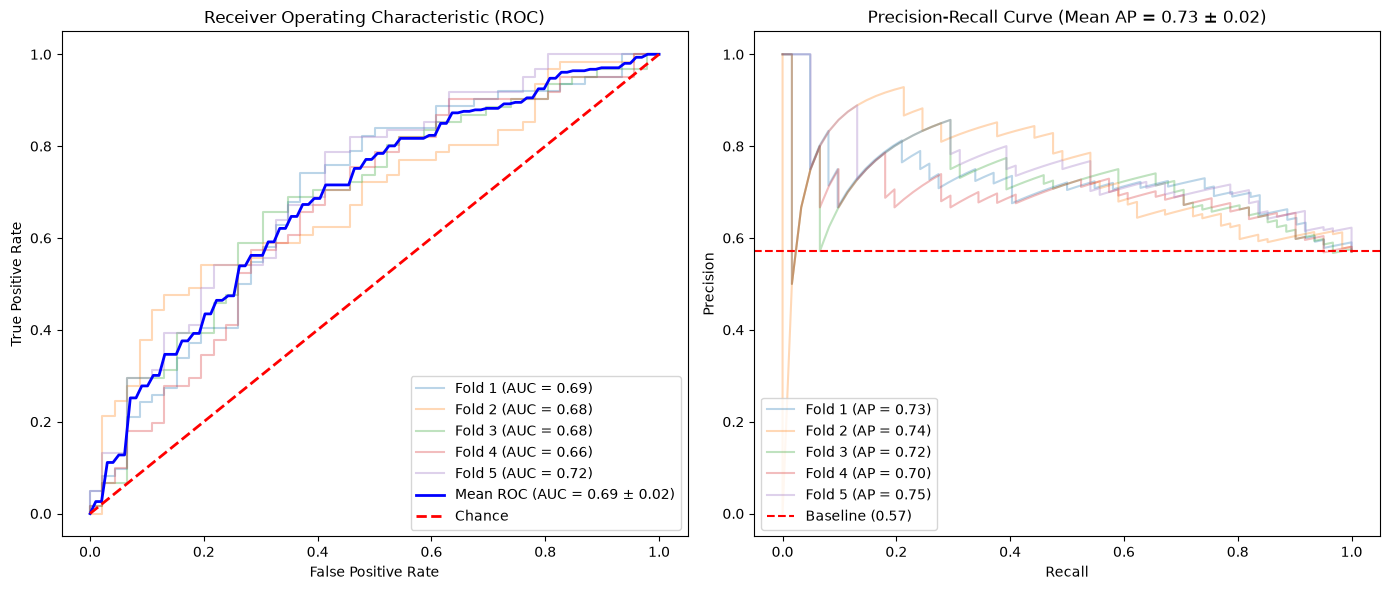

In [14]:
m_matrix_df.set_index("Sample_Name", inplace=True)
generate_evaluation_plots(m_matrix_df, pheno_df, chr_topologies, cell_cols)

In [15]:
import pandas as pd
import numpy as np

def export_unannotated_to_bed(drivers_csv_path, manifest_df, top_n=500, output_bed_path="distal_enhancers.bed"):
    """
    Extracts the top unannotated (intergenic) CpGs from the GAT attention results 
    and formats them as a standard BED file for GREAT pathway analysis.
    """
    print(f"Loading drivers from {drivers_csv_path}...")
    drivers_df = pd.read_csv(drivers_csv_path)
    
    # 1. Isolate the unannotated probes
    # We check for both actual NaNs and the string 'nan' generated during CSV export
    unannotated_df = drivers_df[
        drivers_df['UCSC_RefGene_Name'].isna() | 
        (drivers_df['UCSC_RefGene_Name'].astype(str).str.lower() == 'nan')
    ]
    
    # 2. Thresholding: GREAT works best with a highly selective target set (e.g., top 500-1000)
    top_unannotated = unannotated_df.sort_values(by='Attention_Score', ascending=False).head(top_n)
    
    # 3. Merge with the manifest to pull the precise physical coordinates
    # We need the Chromosome (CHR) and the coordinate (MAPINFO)
    merged_df = top_unannotated.merge(
        manifest_df[['IlmnID', 'CHR', 'MAPINFO']], 
        on='IlmnID', 
        how='inner'
    )
    
    # 4. Construct the BED coordinates (0-based, half-open)
    # MAPINFO points to the 'C'. We subtract 1 for the start, and add 1 to the MAPINFO for the end.
    bed_df = pd.DataFrame({
        'chrom': 'chr' + merged_df['CHR'].astype(str),
        'chromStart': merged_df['MAPINFO'].astype(int) - 1,
        'chromEnd': merged_df['MAPINFO'].astype(int) + 1,
        'name': merged_df['IlmnID'],
        'score': merged_df['Attention_Score']
    })
    
    # 5. Export to BED (Tab-separated, no index, no header for broad compatibility)
    bed_df.to_csv(output_bed_path, sep='\t', header=False, index=False)
    
    print(f"Successfully isolated {len(bed_df)} top intergenic drivers.")
    print(f"Exported BED file to: {output_bed_path}")
    
    return bed_df



In [16]:
bed_output = export_unannotated_to_bed(
    drivers_csv_path="/workspace/results/pd_ensemble_epigenetic_drivers.csv", 
    manifest_df=manifest_df, 
    top_n=500,  # Adjust this based on how strict you want your target list to be
    output_bed_path="/workspace/results/top_500_pd_enhancers.bed"
)

Loading drivers from /workspace/results/pd_ensemble_epigenetic_drivers.csv...
Successfully isolated 500 top intergenic drivers.
Exported BED file to: /workspace/results/top_500_pd_enhancers.bed


In [17]:
import pandas as pd

def export_background_to_bed(manifest_df, common_probes, output_bed_path="gat_background_universe.bed"):
    """
    Filters the Illumina manifest to include only the probes used in the GAT graph,
    and formats them as a standard BED file for GREAT background distribution.
    """
    print(f"Filtering manifest for {len(common_probes)} graph probes...")
    
    # 1. Isolate only the probes that were actually fed into the neural network
    background_df = manifest_df[manifest_df['IlmnID'].isin(common_probes)].copy()
    
    # 2. Drop any probes that might have missing mapping coordinates 
    # (just in case they slipped through earlier filtering)
    background_df = background_df.dropna(subset=['CHR', 'MAPINFO'])
    
    # 3. Construct the BED coordinates (0-based, half-open)
    bed_df = pd.DataFrame({
        'chrom': 'chr' + background_df['CHR'].astype(str),
        'chromStart': background_df['MAPINFO'].astype(int) - 1,
        'chromEnd': background_df['MAPINFO'].astype(int) + 1,
        'name': background_df['IlmnID']
    })
    
    # 4. Export to BED (Tab-separated, no index, no header)
    bed_df.to_csv(output_bed_path, sep='\t', header=False, index=False)
    
    print(f"Successfully generated background BED with {len(bed_df)} probes.")
    print(f"Exported background BED file to: {output_bed_path}")
    
    return bed_df



In [18]:
bg_bed = export_background_to_bed(
    manifest_df=manifest_df, 
    common_probes=common_probes, 
    output_bed_path="/workspace/results/gat_background_universe.bed"
)

Filtering manifest for 421114 graph probes...
Successfully generated background BED with 421114 probes.
Exported background BED file to: /workspace/results/gat_background_universe.bed


In [19]:
import pandas as pd
import gzip

def sanitize_bed_for_great(input_path, output_path, has_score=False):
    print(f"Sanitizing {input_path}...")
    
    # Define columns based on whether it's the test set (has scores) or background (no scores)
    cols = ['chrom', 'start', 'end', 'name', 'score'] if has_score else ['chrom', 'start', 'end', 'name']
    
    df = pd.read_csv(input_path, sep='\t', header=None, names=cols)
    
    # 1. Fix the double 'chrchr' issue if it exists
    df['chrom'] = df['chrom'].astype(str).str.replace('chrchr', 'chr')
    
    # 2. Filter to ONLY standard human chromosomes (chr1-22, X, Y)
    valid_chroms = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']
    df = df[df['chrom'].isin(valid_chroms)]
    
    # 3. Ensure no negative start coordinates
    df.loc[df['start'] < 0, 'start'] = 0
    
    # 4. Save as a gzipped file to prevent GREAT server timeouts
    df.to_csv(output_path, sep='\t', header=False, index=False, compression='gzip')
    
    print(f"Cleaned file saved to {output_path} with {len(df)} valid regions.")

# Clean the test file (Top 500)
sanitize_bed_for_great(
    input_path="/workspace/results/top_500_pd_enhancers.bed", 
    output_path="/workspace/results/top_500_pd_enhancers_clean.bed.gz", 
    has_score=True
)

# Clean the massive background file
sanitize_bed_for_great(
    input_path="/workspace/results/gat_background_universe.bed", 
    output_path="/workspace/results/gat_background_universe_clean.bed.gz", 
    has_score=False
)

Sanitizing /workspace/results/top_500_pd_enhancers.bed...
Cleaned file saved to /workspace/results/top_500_pd_enhancers_clean.bed.gz with 500 valid regions.
Sanitizing /workspace/results/gat_background_universe.bed...
Cleaned file saved to /workspace/results/gat_background_universe_clean.bed.gz with 421114 valid regions.


In [22]:
!apt-get update && apt-get install -y bedtools

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease               
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  bedtools
0 upgraded, 1 newly installed, 0 to remove and 104 not upgraded.
Need to get 563 kB of archives.
After this operation, 1548 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 bedtools amd64 2.30.0+dfsg-2ubuntu0.1 [563 kB]
Fetched 563 kB in 1s (546 kB/s)   
debconf: delaying package configuration, since apt-utils is not installed
Selecting previously unselected package bedtools.
(Reading database ...

In [24]:
%conda install -c conda-forge -c bioconda pybedtools gseapy

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - bioconda
 - defaults
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /opt/conda/envs/rapids-env

  added / updated specs:
    - gseapy
    - pybedtools


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    bedtools-2.31.1            |       h13024bc_3         1.5 MB  bioconda
    gseapy-1.3.1               |  py313h551aa79_0         681 KB  bioconda
    libglvnd-1.7.0             |       ha4b6fd6_5         131 KB  conda-forge
    libopengl-1.7.0            |       ha4b6fd6_5          49 KB  conda-forge
    libopengl-devel-1.7.0      |       ha4b6fd6_5          16 KB  conda-forge
    openssl-3.6.4              |       h781a0a9_0         3.1 MB  conda-forge
    pybedtools-0.12.0          |  py313haa19386_1        12.0 MB  bioconda
    pyopengl-3.1.10            |  

In [6]:
import pandas as pd
import pybedtools
import os

def map_distal_enhancers_to_genes(test_bed_path, output_mapped_path="mapped_genes.csv"):
    """
    Downloads hg19 RefSeq genes and maps intergenic CpGs to their closest target gene.
    """
    print("Downloading hg19 RefSeq gene bounds from UCSC...")
    # Fetch hg19 refGene table. Columns: 2=chrom, 4=txStart, 5=txEnd, 12=name2 (Gene Symbol)
    os.system("curl -s 'http://hgdownload.cse.ucsc.edu/goldenpath/hg19/database/refGene.txt.gz' | zcat | awk -v OFS='\t' '{print $3, $5, $6, $13}' > hg19_refseq.bed")
    
    # Sort the reference file (required for the closest function)
    os.system("sort -k1,1 -k2,2n hg19_refseq.bed > hg19_refseq_sorted.bed")
    
    # 1. Load your top 500 strict BED file and the reference into pybedtools
    enhancers = pybedtools.BedTool(test_bed_path)
    genes = pybedtools.BedTool("hg19_refseq_sorted.bed")
    
    print("Intersecting regions and calculating distances...")
    # 2. Find the closest gene. 
    # - d=True adds a column with the distance in base pairs.
    # - t='first' ensures we only get one gene per CpG to avoid duplicates.
    mapped = enhancers.closest(genes, d=True, t='first')
    
    # 3. Convert the results back to a Pandas DataFrame
    # Columns: [chr, start, end, name, ref_chr, ref_start, ref_end, Gene_Symbol, Distance]
    mapped_df = mapped.to_dataframe(
        names=['chr', 'start', 'end', 'cpg_id', 'ref_chr', 'ref_start', 'ref_end', 'target_gene', 'distance_bp']
    )
    
    # Filter out anything mapped to weird contigs and drop the temporary coordinate columns
    final_df = mapped_df[['cpg_id', 'chr', 'start', 'target_gene', 'distance_bp']].copy()
    final_df = final_df[final_df['target_gene'] != '.'] # Remove unmapped
    
    final_df.to_csv(output_mapped_path, index=False)
    print(f"Successfully mapped {len(final_df)} distal regions to target genes.")
    
    return final_df


In [ ]:
import pandas as pd

def create_strict_great_bed(input_path, output_path, is_test_set=False):
    print(f"Applying strict BED formatting to {input_path}...")
    
    # Load the gzipped files we made previously
    cols = ['chrom', 'start', 'end', 'name', 'score'] if is_test_set else ['chrom', 'start', 'end', 'name']
    df = pd.read_csv(input_path, sep='\t', header=None, names=cols, compression='gzip')
    
    # 1. DROP THE SCORE COLUMN (This removes the decimal that crashes GREAT)
    strict_df = df[['chrom', 'start', 'end', 'name']].copy()
    
    # 2. SORT BY CHROMOSOME AND START POSITION (Required by many genomic parsers)
    # Define a custom sort order so chr10 doesn't come before chr2
    chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']
    strict_df['chrom'] = pd.Categorical(strict_df['chrom'], categories=chrom_order, ordered=True)
    strict_df = strict_df.sort_values(['chrom', 'start']).dropna(subset=['chrom'])
    
    # 3. Export as PLAIN TEXT (Remove gzip just to be safe)
    strict_df.to_csv(output_path, sep='\t', header=False, index=False)
    print(f"Strict BED saved to {output_path} ({len(strict_df)} regions)")

# 1. Strip and sort the test set
create_strict_great_bed(
    "/workspace/results/top_500_pd_enhancers_clean.bed", 
    "/workspace/results/top_500_pd_enhancers_strict.bed", 
    is_test_set=True
)

# 2. Strip and sort the background universe
create_strict_great_bed(
    "/workspace/results/gat_background_universe_clean.bed.gz", 
    "/workspace/results/gat_background_universe_strict.bed", 
    is_test_set=False
)

Applying strict BED formatting to /workspace/results/top_500_pd_enhancers_clean.bed.gz...


FileNotFoundError: [Errno 2] No such file or directory: '/workspace/results/top_500_pd_enhancers_clean.bed.gz'

In [ ]:
mapped_enhancers_df = map_distal_enhancers_to_genes("/workspace/results/top_500_pd_enhancers_strict.bed")
print(mapped_enhancers_df.head())

Intersecting regions and calculating distances...


BEDToolsError: 
Command was:

	bedtools closest -t first -d -b hg19_refseq_sorted.bed -a /workspace/results/top_500_pd_enhancers_clean.bed

Error message was:
Error: Sorted input specified, but the file /workspace/results/top_500_pd_enhancers_clean.bed has the following out of order record
chr21	44261236	44261238	cg24014805	0.0003010468390462


In [8]:
import pandas as pd
import pybedtools
import os

def map_distal_enhancers_to_genes(test_bed_path, output_mapped_path="mapped_genes.csv"):
    """
    Downloads hg19 RefSeq genes and maps intergenic CpGs to their closest target gene.
    """
    print("Downloading hg19 RefSeq gene bounds from UCSC...")
    # Fetch hg19 refGene table. Columns: 2=chrom, 4=txStart, 5=txEnd, 12=name2 (Gene Symbol)
    os.system("curl -s 'http://hgdownload.cse.ucsc.edu/goldenpath/hg19/database/refGene.txt.gz' | zcat | awk -v OFS='\t' '{print $3, $5, $6, $13}' > hg19_refseq.bed")
    
    # Sort the reference file (required for the closest function)
    os.system("sort -k1,1 -k2,2n hg19_refseq.bed > hg19_refseq_sorted.bed")
    
    # 1. Load your top 500 strict BED file and the reference into pybedtools
    enhancers = pybedtools.BedTool(test_bed_path)
    genes = pybedtools.BedTool("hg19_refseq_sorted.bed")
    
    print("Intersecting regions and calculating distances...")
    # 2. Find the closest gene. 
    # - d=True adds a column with the distance in base pairs.
    # - t='first' ensures we only get one gene per CpG to avoid duplicates.
    mapped = enhancers.closest(genes, d=True, t='first')
    
    # 3. Convert the results back to a Pandas DataFrame
    # Columns: [chr, start, end, name, ref_chr, ref_start, ref_end, Gene_Symbol, Distance]
    mapped_df = mapped.to_dataframe(
        names=['chr', 'start', 'end', 'cpg_id', 'ref_chr', 'ref_start', 'ref_end', 'target_gene', 'distance_bp']
    )
    
    # Filter out anything mapped to weird contigs and drop the temporary coordinate columns
    final_df = mapped_df[['cpg_id', 'chr', 'start', 'target_gene', 'distance_bp']].copy()
    final_df = final_df[final_df['target_gene'] != '.'] # Remove unmapped
    
    final_df.to_csv(output_mapped_path, index=False)
    print(f"Successfully mapped {len(final_df)} distal regions to target genes.")
    
    return final_df

# Execute the mapping
# mapped_enhancers_df = map_distal_enhancers_to_genes("/workspace/results/top_500_pd_enhancers_strict.bed")
# print(mapped_enhancers_df.head())

In [9]:
mapped_enhancers_df = map_distal_enhancers_to_genes("/workspace/results/top_500_pd_enhancers_strict.bed")

Intersecting regions and calculating distances...
Successfully mapped 500 distal regions to target genes.


In [10]:
import gseapy as gp
import matplotlib.pyplot as plt

# 1. Apply a biological distance filter (e.g., max 50kb from the TSS)
strict_mapped_df = mapped_enhancers_df[mapped_enhancers_df['distance_bp'] <= 50000]

print("Extracting unique target genes...")
# Get the filtered unique genes
target_genes = strict_mapped_df['target_gene'].dropna().unique().tolist()
print(f"Filtered down to {len(target_genes)} high-confidence target genes.")

# 2. Query multiple, highly granular databases
# gseapy can accept a list of libraries at once
databases = [
    'GO_Biological_Process_2023', 
    'Reactome_2022', 
    'KEGG_2021_Human'
]

print(f"Running Enrichment against: {databases}...")
enrichment = gp.enrichr(
    gene_list=target_genes,
    gene_sets=databases,
    organism='human',
    outdir=None 
)

results_df = enrichment.results

# 3. Check for Nominally Significant (before strict FDR) AND strictly significant terms
# Sometimes looking at P-value < 0.05 before FDR gives excellent biological clues for sparse sets
nominally_sig = results_df[results_df['P-value'] < 0.01]
fdr_sig = results_df[results_df['Adjusted P-value'] < 0.05]

print(f"\nFound {len(nominally_sig)} nominally significant terms (P < 0.01)")
print(f"Found {len(fdr_sig)} strictly significant terms (FDR < 0.05)")

if len(fdr_sig) > 0:
    # Plot strictly significant
    gp.barplot(enrichment.results, column="Adjusted P-value", top_term=10, figsize=(8, 5))
    plt.show()
elif len(nominally_sig) > 0:
    print("\nDisplaying top 10 nominal pathways (no FDR):")
    print(nominally_sig[['Gene_set', 'Term', 'P-value', 'Overlap']].head(10))

Extracting unique target genes...
Filtered down to 122 high-confidence target genes.
Running Enrichment against: ['GO_Biological_Process_2023', 'Reactome_2022', 'KEGG_2021_Human']...

Found 34 nominally significant terms (P < 0.01)
Found 0 strictly significant terms (FDR < 0.05)

Displaying top 10 nominal pathways (no FDR):
                     Gene_set  \
0  GO_Biological_Process_2023   
1  GO_Biological_Process_2023   
2  GO_Biological_Process_2023   
3  GO_Biological_Process_2023   
4  GO_Biological_Process_2023   
5  GO_Biological_Process_2023   
6  GO_Biological_Process_2023   
7  GO_Biological_Process_2023   
8  GO_Biological_Process_2023   
9  GO_Biological_Process_2023   

                                                Term   P-value Overlap  
0  Cerebral Cortex Neuron Differentiation (GO:002...  0.000365     2/5  
1  Ventricular Cardiac Muscle Cell Membrane Repol...  0.000760     2/7  
2  Negative Regulation Of Delayed Rectifier Potas...  0.001292     2/9  
3  Negative Regula

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_nominal_pathways(nominally_sig_df, top_n=12):
    # 1. Prepare the DataFrame
    # Take the top N pathways based on P-value
    plot_df = nominally_sig_df.sort_values('P-value').head(top_n).copy()
    
    # Calculate -log10(p-value) for standard visualization
    plot_df['-log10(P-value)'] = -np.log10(plot_df['P-value'])
    
    # Extract the number of overlapping genes from the 'Overlap' column (e.g., "4/150" -> 4)
    plot_df['Gene_Count'] = plot_df['Overlap'].apply(lambda x: int(x.split('/')[0]))
    
    # Clean up GO terms (Remove the " (GO:0001234)" suffix for a cleaner y-axis)
    plot_df['Clean_Term'] = plot_df['Term'].apply(lambda x: x.split(' (GO:')[0] if 'GO:' in x else x)
    
    # Sort descending so the most significant is at the top of the plot
    plot_df = plot_df.sort_values('-log10(P-value)', ascending=False)
    
    # 2. Create the Figure
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    # 3. Build the Scatter/Dot Plot
    bubble = sns.scatterplot(
        data=plot_df,
        x='-log10(P-value)',
        y='Clean_Term',
        size='Gene_Count',
        hue='Gene_set',        # Color by Database (GO, KEGG, Reactome)
        sizes=(150, 600),      # Control the min/max bubble sizes
        alpha=0.8,             # Slight transparency looks more professional
        palette="viridis",     # A colorblind-friendly, modern palette
        edgecolor='black',
        linewidth=0.5
    )
    
    # 4. Formatting and Labels
    plt.title("Pathway Enrichment of Unannotated Distal Enhancers", fontsize=16, pad=15)
    plt.xlabel("-log$_{10}$(Nominal P-value)", fontsize=12)
    plt.ylabel("") # Leave Y-label blank as the pathway names speak for themselves
    
    # Adjust the legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Database & Gene Count")
    
    # Add a subtle vertical dashed line at P=0.01 (which is -log10(0.01) = 2.0)
    plt.axvline(x=2.0, color='red', linestyle='--', alpha=0.5, zorder=0)
    plt.text(2.02, plt.gca().get_ylim()[1]-0.2, 'P = 0.01', color='red', alpha=0.8, fontsize=10)

    # Clean up layout and display
    plt.tight_layout()
    
    # Optional: Save for your thesis/poster
    # plt.savefig("/workspace/results/nominal_enhancer_dotplot.pdf", format="pdf", bbox_inches="tight")
    
    plt.show()


/tmp/ipykernel_1616/597294806.py:54: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


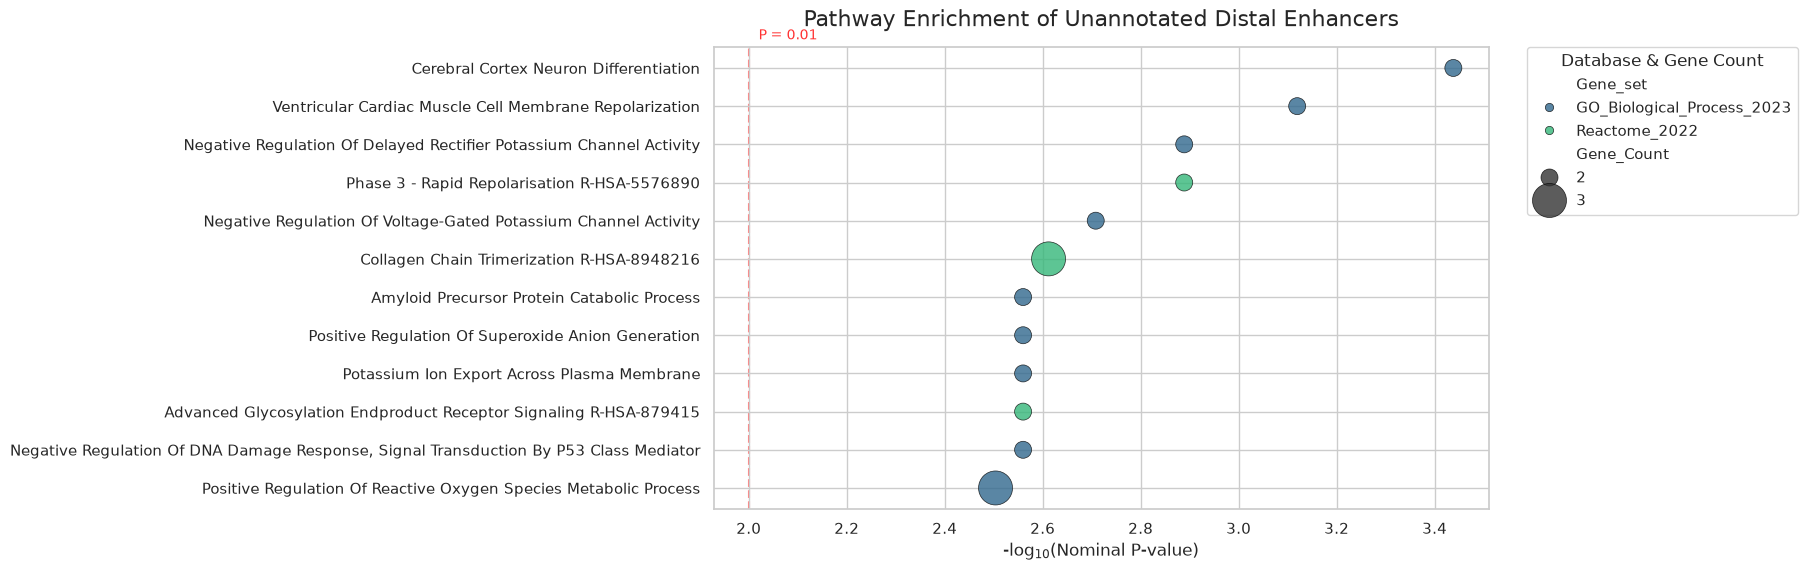

In [12]:

plot_nominal_pathways(nominally_sig)